# ch07 연속형 확률변수

- 1차원 연속형 확률변수

In [81]:
import numpy as np
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [82]:
from scipy import integrate
import warnings

# 적분에 관한 warning을 출력하지 않도록 한다
warnings.filterwarnings('ignore',
                        category=integrate.IntegrationWarning)

In [83]:
x_range = np.array([0,1,2,3])

In [129]:
def f(x):
    if x_range[0] <= x < x_range[1]:
        return x
    elif x_range[1] <= x < x_range[2]:
        return 1
    elif x_range[2] <= x <= x_range[3]:
        return 3-x
    else:
        return 0

In [85]:
X = [x_range, f]

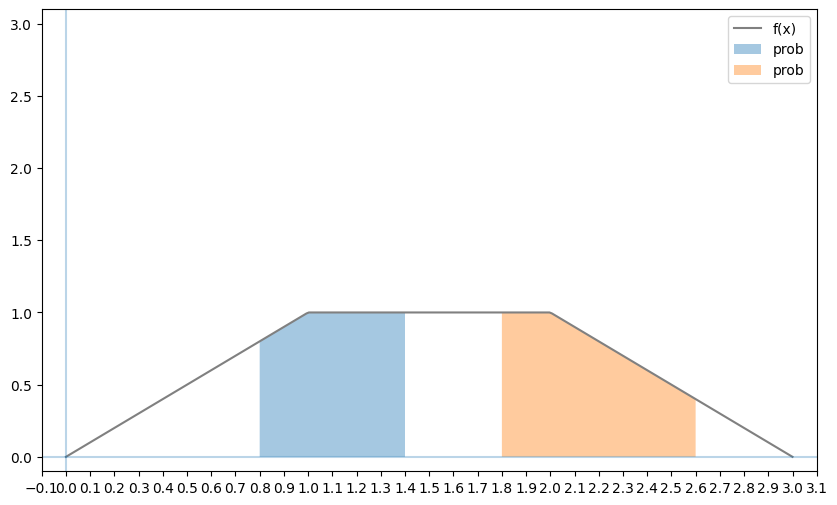

In [86]:
xs = np.linspace(x_range[0], x_range[3], 300)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [f(x) for x in xs], label='f(x)', color='gray')
ax.hlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(0, -0.1, 3.1, alpha=0.3)
# ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

xs = np.linspace(0.8, 1.4, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob', alpha = 0.4)
xs = np.linspace(1.8, 2.6, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob', alpha = 0.4)

ax.set_xticks(np.arange(-0.1, 3.2, 0.1))
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.1, 3.1)
ax.legend()

plt.show()

In [87]:
integrate.quad(f, 0.8, 1.4)

(0.580, 0.000)

In [88]:
integrate.quad(f, 1.8, 2.6)

(0.620, 0.000)

In [89]:
from scipy.optimize import minimize_scalar

res = minimize_scalar(f)
# 함수의 최솟값은 fun이라는 인스턴스 변수에
res.fun

np.int64(0)

In [90]:
integrate.quad(f, -np.inf, np.inf)[0]

2.000

In [158]:
def fnew(x):
    return f(x) * 0.5

In [159]:
def F(x):
    return integrate.quad(fnew, -np.inf, x)[0]

In [120]:
F(2.6) - F(1.8)

0.310

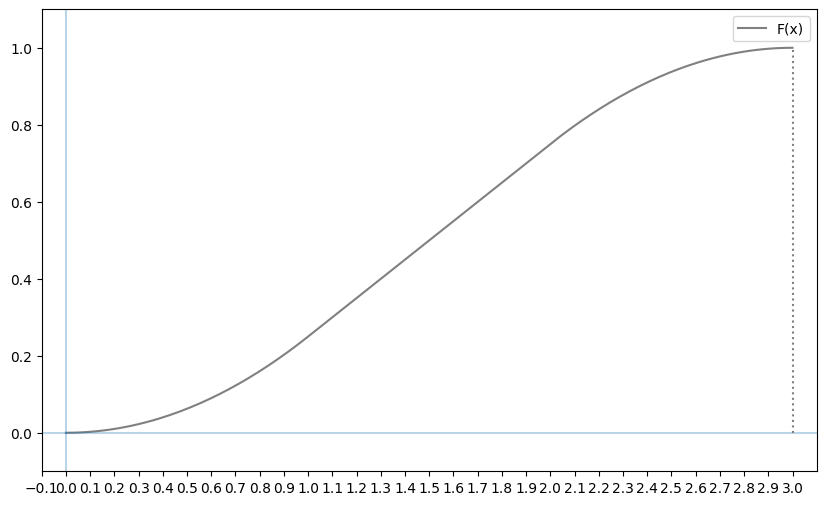

In [125]:
xs = np.linspace(x_range[0], x_range[3], 300)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [F(x) for x in xs], label='F(x)', color='gray')
ax.hlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(0, -0.1, 3.1, alpha=0.3)
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.1, 3.1, 0.1))
ax.set_xlim(-0.1, 3.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()

##### 연습문제

코드로 구현하여 문제를 풀어주세요
- k 값
- 기댓값
- 분산
- F(x) 그래프
- Y = -2X+5 선형변환
- 5번의 기댓값, 분산
- 그래프 비교

In [227]:
x_range = np.array([0,1,2,3,4])

In [228]:
#1번
k = 0.5
def fx(x):
    if x_range[0] <= x < x_range[1]:
        return k * x
    elif x_range[1] <= x < x_range[2]:
        return k * (2-x)
    elif x_range[2] <= x <= x_range[3]:
        return k * (x-2)
    elif x_range[3] <= x <= x_range[4]:
        return k * (4-x)
    else:
        return 0
    
print("k의 값은 " + str(k) + "이다.")

k의 값은 0.5이다.


In [229]:
X = [x_range, fx]

In [230]:
integrate.quad(fx, -np.inf, np.inf)[0]

1.000

In [231]:
#2번
def E(X, g = lambda x: x):
    x_range, f = X
    def integrand(x):
        return x * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

E(X)

2.000

In [232]:
#3번
def V(X, g = lambda x: x):
    x_range, f = X
    mean = E(X, g)
    def integrand(x):
        return (x - mean) ** 2 * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

V(X)

1.167

In [233]:
#4번
def Fx(x):
    return integrate.quad(fx, -np.inf, x)[0]

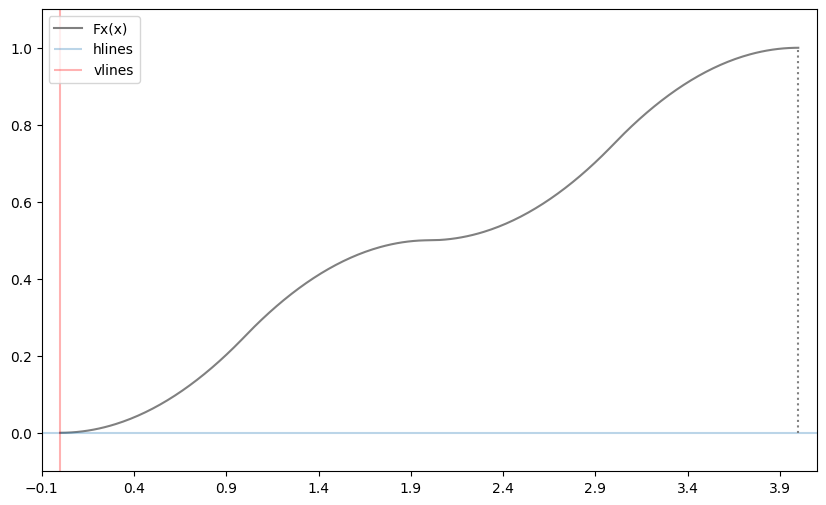

In [234]:
xs = np.linspace(x_range[0], x_range[4], 400)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [Fx(x) for x in xs], label='Fx(x)', color='gray')
ax.hlines(0, -0.1, 4.1, alpha=0.3, label = 'hlines')
ax.vlines(0, -0.1, 4.1, alpha=0.3, label = 'vlines', colors = 'red')
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.1, 4.1, 0.5))
ax.set_xlim(-0.1, 4.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()

In [235]:
#5번
y_range = np.array([5, 3])

def g(y):
    if y_range[1] <= y <= y_range[0]:
        return (y - 5) / (-2) * k
    else:
        return 0
    
def G(y):
    return integrate.quad(g, y_range[1], y)[0]

In [237]:
E_Y = E(X, g=lambda x: -2*x + 5)
E_Ys2 = E(X, g=lambda x: (-2*x + 5)**2)
V_Y = E_Ys2 - E_Y**2

In [238]:
#6번
print(f"Y의 기댓값: {E_Y:.3f}")
print(f"Y의 분산: {V_Y:.3f}")

Y의 기댓값: 2.000
Y의 분산: -2.000


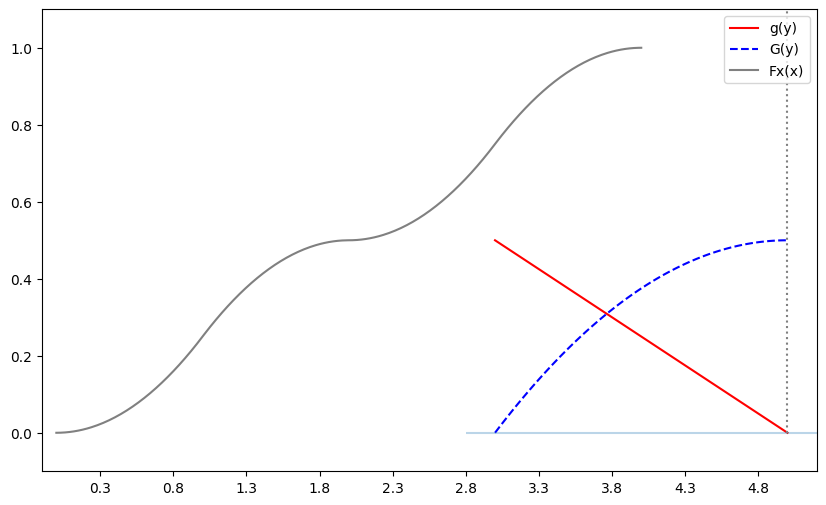

In [241]:
ys = np.linspace(y_range[1], y_range[0], 100)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(ys, [g(y) for y in ys],
        label='g(y)', color='red')
ax.plot(ys, [G(y) for y in ys],
        label='G(y)', ls='--', color='blue')
ax.plot(xs, [Fx(x) for x in xs], label='Fx(x)', color='gray')
ax.hlines(0, 2.8, 5.2, alpha=0.3)
ax.vlines(ys.max(), 0, 5, linestyles=':', color='gray')

ax.set_xticks(np.arange(-0.2, 5.2, 0.5))
ax.set_xlim(-0.1, 5.2)
ax.set_ylim(-0.1, 1.1)
ax.legend()

plt.show()